In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('/content/churn_scaled.csv')

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Number of rows: 6742
Number of columns: 1


churn_scaled
gender SeniorCitizen Dependents tenure              PhoneService MultipleLines InternetService MonthlyCharges      Churn Contract_One year  Contract_Two year
0      0             0          -1.3128745474321000 0            0             0               -1.3762278735972200 1     0                                  0
1      0             0          0.33103835840880100 1            0             0               -1.3762278735972200 0     1                                  0
0      0             1          0.7831144075150480  1            0             0               -1.5783988003368400 0     0                                  0
                     0          -1.3128745474321000 1            0             0               0.3422250036895660  1     1                                  0

In [4]:
with open('/content/churn_scaled.csv', 'r') as file:
    first_line = file.readline()

print(first_line)

churn_scaled



In [5]:
with open('/content/churn_scaled.csv', 'r') as file:
    for i in range(6):
        print(f"Line {i}: {repr(file.readline())}")

Line 0: 'churn_scaled\n'
Line 1: 'gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Churn,Contract_One year,Contract_Two year\n'
Line 2: '0,0,0,-1.3128745474321000,0,0,0,-1.3762278735972200,1,0,0\n'
Line 3: '1,0,0,0.33103835840880100,1,0,0,-1.3762278735972200,0,1,0\n'
Line 4: '0,0,1,0.7831144075150480,1,0,0,-1.5783988003368400,0,0,0\n'
Line 5: '0,0,0,-1.3128745474321000,1,0,0,0.3422250036895660,1,1,0\n'


In [6]:
df = pd.read_csv('/content/churn_scaled.csv', skiprows=1)

print("Dataset loaded correctly!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded correctly!
Number of rows: 6741
Number of columns: 11


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Churn,Contract_One year,Contract_Two year
0,0,0,0,-1.312875,0,0,0,-1.376228,1,0,0
1,1,0,0,0.331038,1,0,0,-1.376228,0,1,0
2,0,0,1,0.783114,1,0,0,-1.578399,0,0,0
3,0,0,0,-1.312875,1,0,0,0.342225,1,1,0
4,1,0,0,1.399582,1,0,1,-0.500154,0,0,0


In [7]:
print("All columns in the scaled dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

All columns in the scaled dataset:

1. gender
2. SeniorCitizen
3. Dependents
4. tenure
5. PhoneService
6. MultipleLines
7. InternetService
8. MonthlyCharges
9. Churn
10. Contract_One year
11. Contract_Two year


In [8]:
# Create the dataset to be used for clustering
# Churn is excluded because it is the outcome we will compare with the clusters later

cluster_df = df.drop(columns=['Churn'])

print("Clustering dataset prepared successfully!")
print("Number of rows:", cluster_df.shape[0])
print("Number of features used for clustering:", cluster_df.shape[1])

print("\nFeatures used for clustering:")
for column in cluster_df.columns:
    print("-", column)

Clustering dataset prepared successfully!
Number of rows: 6741
Number of features used for clustering: 10

Features used for clustering:
- gender
- SeniorCitizen
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- MonthlyCharges
- Contract_One year
- Contract_Two year


In [9]:
print("Data types of clustering features:")
print(cluster_df.dtypes)

print("\nNon-numeric columns:")
print(cluster_df.select_dtypes(exclude=np.number).columns.tolist())

print("\nMissing values in clustering data:")
print(cluster_df.isnull().sum().sum())

Data types of clustering features:
gender                 int64
SeniorCitizen          int64
Dependents             int64
tenure               float64
PhoneService           int64
MultipleLines          int64
InternetService        int64
MonthlyCharges       float64
Contract_One year      int64
Contract_Two year      int64
dtype: object

Non-numeric columns:
[]

Missing values in clustering data:
0


In [10]:
# Elbow Method to identify the optimal number of clusters

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_df)
    inertia.append(kmeans.inertia_)

print("Inertia values:\n")

for k, value in zip(K, inertia):
    print(f"k = {k}: {value:.2f}")

Inertia values:

k = 2: 17918.02
k = 3: 14634.40
k = 4: 12956.38
k = 5: 12291.47
k = 6: 11757.57
k = 7: 11312.20
k = 8: 10942.18
k = 9: 10643.53
k = 10: 10418.41


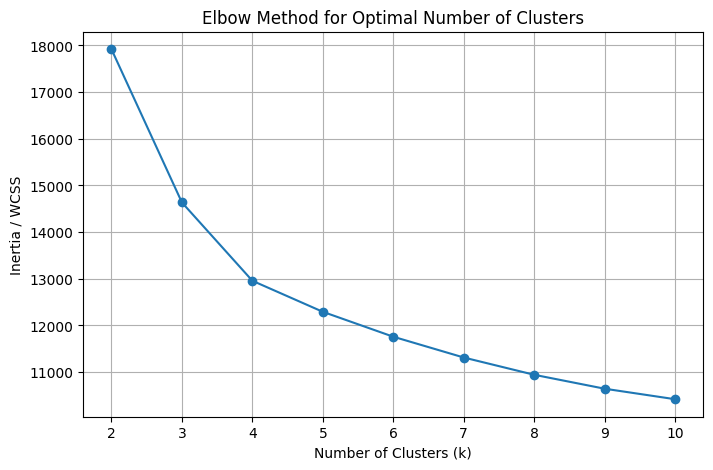

In [11]:
# Plot the Elbow Method graph

plt.figure(figsize=(8, 5))

plt.plot(
    list(K),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / WCSS')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(list(K))
plt.grid(True)

plt.show()

In [12]:
# Calculate Silhouette Scores for different numbers of clusters

silhouette_scores = []

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels_temp = kmeans.fit_predict(cluster_df)

    score = silhouette_score(
        cluster_df,
        cluster_labels_temp
    )

    silhouette_scores.append(score)

    print(f"k = {k}: Silhouette Score = {score:.4f}")

k = 2: Silhouette Score = 0.2233
k = 3: Silhouette Score = 0.2134
k = 4: Silhouette Score = 0.1998
k = 5: Silhouette Score = 0.1763
k = 6: Silhouette Score = 0.1527
k = 7: Silhouette Score = 0.1403
k = 8: Silhouette Score = 0.1367
k = 9: Silhouette Score = 0.1368
k = 10: Silhouette Score = 0.1308


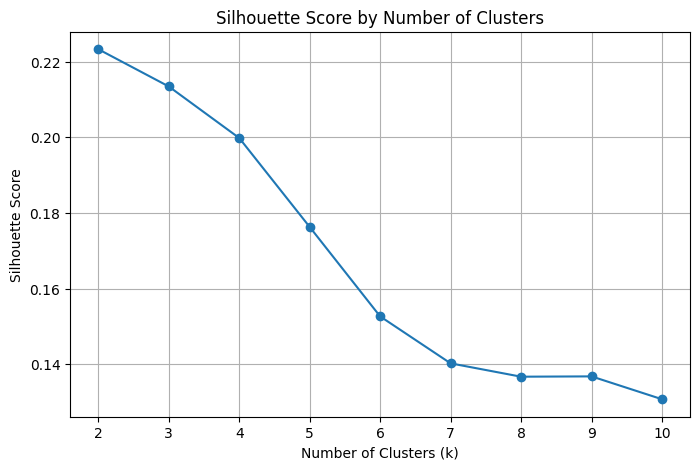

In [13]:
# Plot Silhouette Scores

plt.figure(figsize=(8, 5))

plt.plot(
    list(K),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.xticks(list(K))
plt.grid(True)

plt.show()

In [14]:
# Train the final K-Means model using k = 4

optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(cluster_df)

print("Final K-Means model trained successfully!")
print("Number of clusters:", optimal_k)
print("Final model inertia:", round(final_kmeans.inertia_, 2))

Final K-Means model trained successfully!
Number of clusters: 4
Final model inertia: 12956.38


In [15]:
# Add cluster assignments to the dataset

df['Cluster'] = cluster_labels

print("Cluster labels added successfully!")

df.head()

Cluster labels added successfully!


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Churn,Contract_One year,Contract_Two year,Cluster
0,0,0,0,-1.312875,0,0,0,-1.376228,1,0,0,0
1,1,0,0,0.331038,1,0,0,-1.376228,0,1,0,2
2,0,0,1,0.783114,1,0,0,-1.578399,0,0,0,2
3,0,0,0,-1.312875,1,0,0,0.342225,1,1,0,3
4,1,0,0,1.399582,1,0,1,-0.500154,0,0,0,2


In [16]:
# Number of customers in each cluster

cluster_counts = df['Cluster'].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

print("\nPercentage of customers in each cluster:")

cluster_percentages = (
    df['Cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(cluster_percentages.round(2))

Number of customers in each cluster:
Cluster
0    1586
1    1882
2    1123
3    2150
Name: count, dtype: int64

Percentage of customers in each cluster:
Cluster
0    23.53
1    27.92
2    16.66
3    31.89
Name: proportion, dtype: float64


In [17]:
# Create a profile of each cluster

cluster_profile = df.groupby('Cluster')[cluster_df.columns].mean()

print("Average feature values for each cluster:")

cluster_profile.round(2)

Average feature values for each cluster:


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Contract_One year,Contract_Two year
Cluster,,,,,,,,,,
0,0.52,0.07,0.33,-0.89,0.78,0.43,0.44,-1.08,0.24,0.24
1,0.50,0.22,0.34,1.06,1.00,0.43,0.45,0.92,0.21,0.24
2,0.51,0.08,0.45,0.88,0.73,0.40,0.44,-1.04,0.22,0.24
3,0.49,0.24,0.18,-0.73,1.00,0.42,0.43,0.53,0.19,0.25


In [18]:
# Display the complete cluster profile clearly

for cluster in cluster_profile.index:
    print(f"\n========== CLUSTER {cluster} ==========")
    print(cluster_profile.loc[cluster].round(2))


========== CLUSTER 0 ==========
gender               0.52
SeniorCitizen        0.07
Dependents           0.33
tenure              -0.89
PhoneService         0.78
MultipleLines        0.43
InternetService      0.44
MonthlyCharges      -1.08
Contract_One year    0.24
Contract_Two year    0.24
Name: 0, dtype: float64

========== CLUSTER 1 ==========
gender               0.50
SeniorCitizen        0.22
Dependents           0.34
tenure               1.06
PhoneService         1.00
MultipleLines        0.43
InternetService      0.45
MonthlyCharges       0.92
Contract_One year    0.21
Contract_Two year    0.24
Name: 1, dtype: float64

========== CLUSTER 2 ==========
gender               0.51
SeniorCitizen        0.08
Dependents           0.45
tenure               0.88
PhoneService         0.73
MultipleLines        0.40
InternetService      0.44
MonthlyCharges      -1.04
Contract_One year    0.22
Contract_Two year    0.24
Name: 2, dtype: float64

========== CLUSTER 3 ==========
gender          

In [19]:
# Analyse churn rate within each cluster

churn_by_cluster = df.groupby('Cluster')['Churn'].agg(
    Customer_Count='count',
    Churned_Customers='sum',
    Churn_Rate='mean'
)

churn_by_cluster['Churn_Rate_Percentage'] = (
    churn_by_cluster['Churn_Rate'] * 100
)

print("Churn analysis by cluster:")
display(
    churn_by_cluster[
        ['Customer_Count',
         'Churned_Customers',
         'Churn_Rate_Percentage']
    ].round(2)
)

Churn analysis by cluster:


,Customer_Count,Churned_Customers,Churn_Rate_Percentage
Cluster,,,
0,1586,395,24.91
1,1882,294,15.62
2,1123,54,4.81
3,2150,1048,48.74


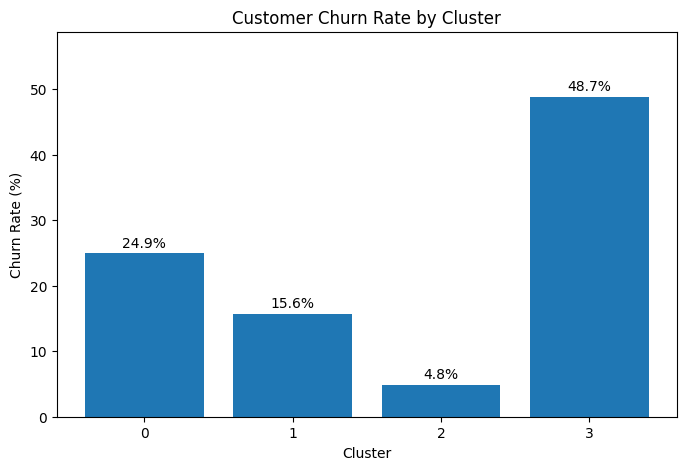

In [20]:
# Visualise churn rate by cluster

churn_rates = (
    df.groupby('Cluster')['Churn'].mean() * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    churn_rates.index.astype(str),
    churn_rates.values
)

plt.xlabel('Cluster')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Cluster')

# Add percentage labels above bars
for bar, value in zip(bars, churn_rates.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.ylim(0, max(churn_rates.values) + 10)
plt.show()

In [21]:
# Reduce clustering features to 2 dimensions using PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(cluster_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = cluster_labels

print("PCA completed successfully!")
print(
    "Total variance explained by PC1 and PC2:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

pca_df.head()

PCA completed successfully!
Total variance explained by PC1 and PC2: 57.43 %


,PC1,PC2,Cluster
0,-1.955054,0.024130,0
1,-0.770430,1.138295,2
2,-0.582270,1.725684,2
3,-0.689587,-1.207922,3
4,0.614377,1.307906,2


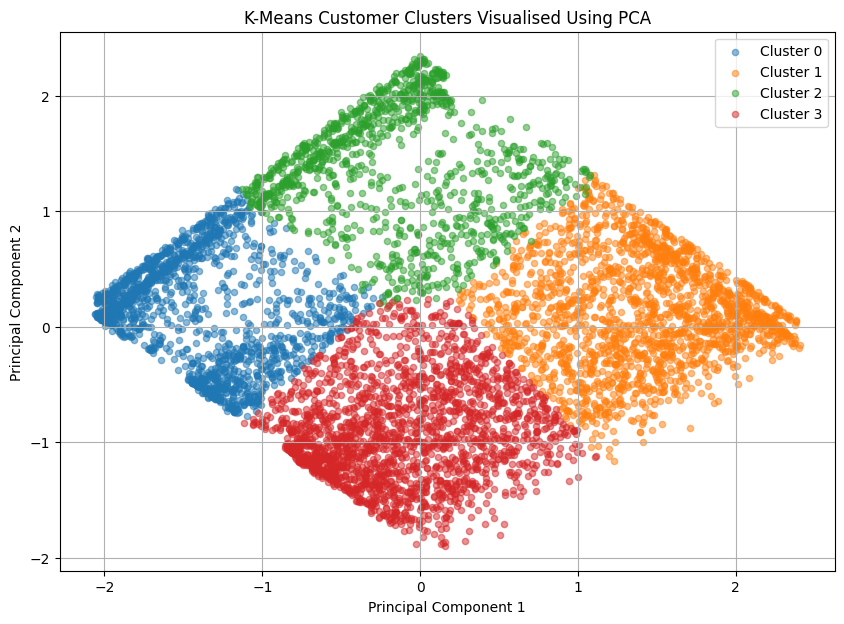

In [22]:
# Visualise the K-Means clusters using PCA

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['Cluster'].unique()):

    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.5,
        s=20
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Customer Clusters Visualised Using PCA')
plt.legend()
plt.grid(True)

plt.show()

In [23]:
# Add meaningful labels to the four customer clusters

cluster_names = {
    0: 'Short-Tenure Lower-Charge',
    1: 'Long-Tenure Higher-Charge',
    2: 'Long-Tenure Lower-Charge',
    3: 'Short-Tenure Higher-Charge'
}

df['Cluster_Label'] = df['Cluster'].map(cluster_names)

print("Cluster labels added successfully!")

print(
    df[['Cluster', 'Cluster_Label']]
    .value_counts()
    .sort_index()
)

Cluster labels added successfully!
Cluster  Cluster_Label             
0        Short-Tenure Lower-Charge     1586
1        Long-Tenure Higher-Charge     1882
2        Long-Tenure Lower-Charge      1123
3        Short-Tenure Higher-Charge    2150
Name: count, dtype: int64


In [24]:
# Create final cluster summary

final_summary = pd.DataFrame({
    'Customers': df.groupby('Cluster').size(),
    'Percentage': df.groupby('Cluster').size() / len(df) * 100,
    'Churn_Rate': df.groupby('Cluster')['Churn'].mean() * 100,
    'Average_Tenure_Scaled': df.groupby('Cluster')['tenure'].mean(),
    'Average_MonthlyCharges_Scaled':
        df.groupby('Cluster')['MonthlyCharges'].mean()
})

final_summary['Cluster_Label'] = final_summary.index.map(cluster_names)

final_summary = final_summary[
    [
        'Cluster_Label',
        'Customers',
        'Percentage',
        'Churn_Rate',
        'Average_Tenure_Scaled',
        'Average_MonthlyCharges_Scaled'
    ]
]

display(final_summary.round(2))

,Cluster_Label,Customers,Percentage,Churn_Rate,Average_Tenure_Scaled,Average_MonthlyCharges_Scaled
Cluster,,,,,,
0,Short-Tenure Lower-Charge,1586,23.53,24.91,-0.89,-1.08
1,Long-Tenure Higher-Charge,1882,27.92,15.62,1.06,0.92
2,Long-Tenure Lower-Charge,1123,16.66,4.81,0.88,-1.04
3,Short-Tenure Higher-Charge,2150,31.89,48.74,-0.73,0.53


In [25]:
# Save dataset containing cluster assignments and labels

df.to_csv(
    '/content/customer_clusters.csv',
    index=False
)

print("customer_clusters.csv saved successfully!")

customer_clusters.csv saved successfully!


In [26]:
import joblib

joblib.dump(
    final_kmeans,
    '/content/kmeans_customer_churn_model.pkl'
)

print("K-Means model saved successfully!")

K-Means model saved successfully!


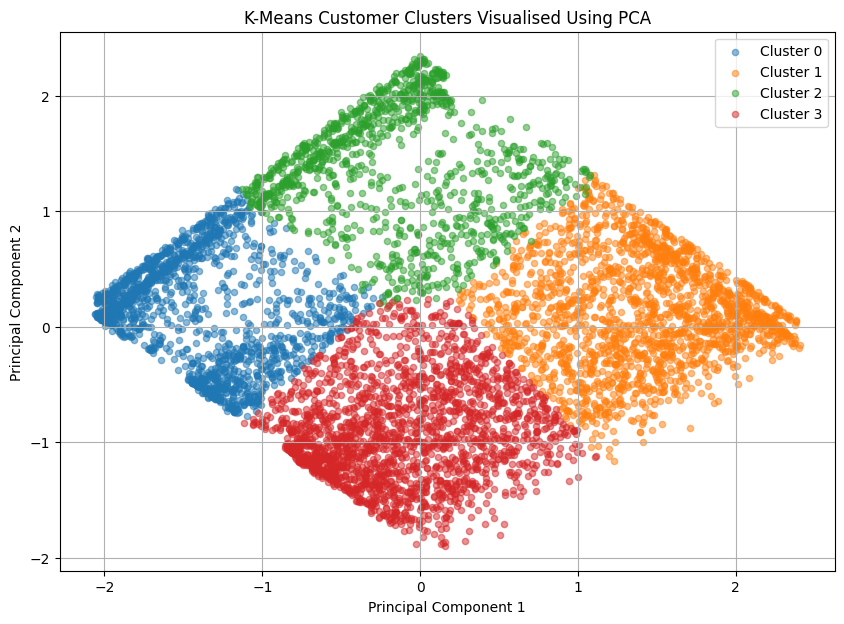

PCA visualisation saved successfully!


In [27]:
# Save PCA cluster visualisation

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['Cluster'].unique()):

    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.5,
        s=20
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Customer Clusters Visualised Using PCA')
plt.legend()
plt.grid(True)

plt.savefig(
    '/content/kmeans_clusters_pca.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("PCA visualisation saved successfully!")

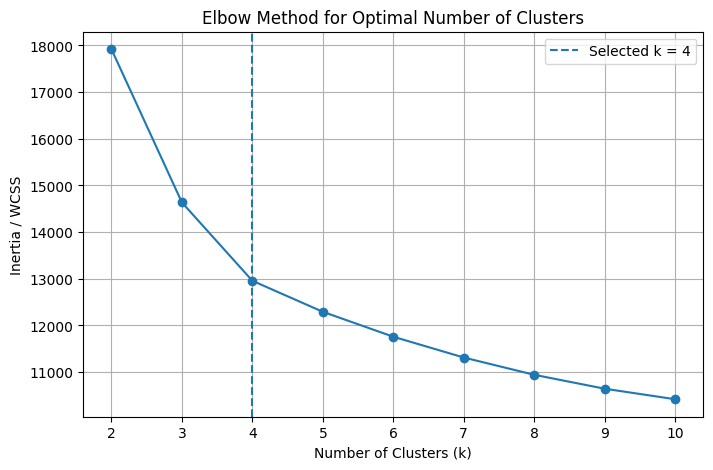

Elbow Method graph saved successfully!


In [28]:
# Save Elbow Method graph

plt.figure(figsize=(8, 5))

plt.plot(
    list(K),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / WCSS')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(list(K))
plt.grid(True)

# Highlight selected k = 4
plt.axvline(
    x=4,
    linestyle='--',
    label='Selected k = 4'
)

plt.legend()

plt.savefig(
    '/content/elbow_method.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Elbow Method graph saved successfully!")

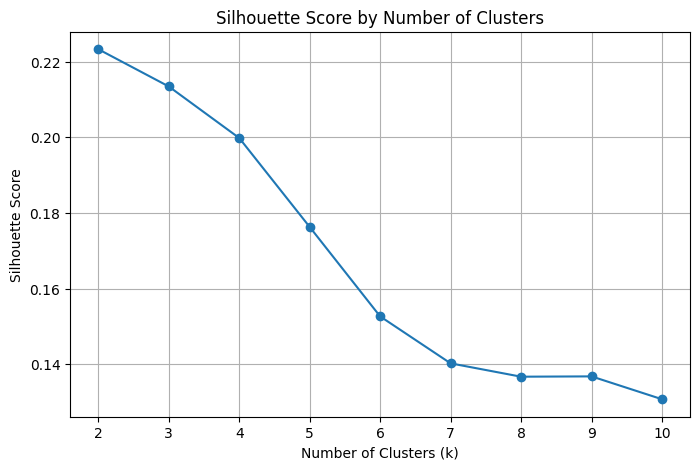

Silhouette Score graph saved successfully!


In [29]:
# Save Silhouette Score graph

plt.figure(figsize=(8, 5))

plt.plot(
    list(K),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.xticks(list(K))
plt.grid(True)

plt.savefig(
    '/content/silhouette_scores.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Silhouette Score graph saved successfully!")

In [30]:
# Save final cluster summary

final_summary.to_csv(
    '/content/cluster_summary.csv'
)

print("Cluster summary saved successfully!")

display(final_summary.round(2))

Cluster summary saved successfully!


,Cluster_Label,Customers,Percentage,Churn_Rate,Average_Tenure_Scaled,Average_MonthlyCharges_Scaled
Cluster,,,,,,
0,Short-Tenure Lower-Charge,1586,23.53,24.91,-0.89,-1.08
1,Long-Tenure Higher-Charge,1882,27.92,15.62,1.06,0.92
2,Long-Tenure Lower-Charge,1123,16.66,4.81,0.88,-1.04
3,Short-Tenure Higher-Charge,2150,31.89,48.74,-0.73,0.53


In [31]:
# Save complete cluster profiles

cluster_profile.to_csv(
    '/content/cluster_profiles.csv'
)

print("Cluster profiles saved successfully!")

display(cluster_profile.round(2))

Cluster profiles saved successfully!


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Contract_One year,Contract_Two year
Cluster,,,,,,,,,,
0,0.52,0.07,0.33,-0.89,0.78,0.43,0.44,-1.08,0.24,0.24
1,0.50,0.22,0.34,1.06,1.00,0.43,0.45,0.92,0.21,0.24
2,0.51,0.08,0.45,0.88,0.73,0.40,0.44,-1.04,0.22,0.24
3,0.49,0.24,0.18,-0.73,1.00,0.42,0.43,0.53,0.19,0.25
